# Used Car Price-Value Ratio Arbitrage Study

**Question:** Which used cars in the SGD $60K–$80K bracket offer the best value?

**Data:** Used car listings from SGCarMart, fetched 2026-05-23.
Filters: 2016+ registration, passenger cars only, COE-renewed cars excluded.

In [1]:
import json, re
from datetime import datetime, date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)

NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR if (NB_DIR / "data").exists() else NB_DIR.parent
DATA_FILE = PROJECT_ROOT / "data/used_cars/sgd-passenger/latest.json"
CONFIG_FILE = PROJECT_ROOT / "data/used_cars/sgd-passenger/config.json"

with open(CONFIG_FILE) as f:
    watch_config = json.load(f)
print("Watch config:", json.dumps(watch_config, indent=2))

Watch config: {
  "name": "sgd-passenger",
  "filters": {
    "min_price": 60000,
    "max_price": 100000,
    "year_from": 2016,
    "vts": 2,
    "avl": "a",
    "sortby": "REG_DESC",
    "limit": 100
  },
  "max_pages": 50,
  "exclude_coe_renewed": true
}


In [2]:
with open(DATA_FILE) as f:
    raw = json.load(f)

listings = list(raw.values())
print(f"Loaded {len(listings)} listings")

# Derive reference date from the data itself
TODAY = datetime.strptime(listings[0]["posted_date"], "%d-%b-%Y").date()
YEAR_FROM = TODAY.year - 10
print(f"Reference date: {TODAY}, year_from: {YEAR_FROM}")
print(f"Fields: {list(listings[0].keys())}")

Loaded 2127 listings
Reference date: 2026-05-23, year_from: 2016
Fields: ['id', 'title', 'url', 'price', 'depreciation', 'reg_date', 'coe_left', 'mileage', 'eng_cap', 'owners', 'is_direct_owner', 'is_premium_ad', 'dealer', 'posted_date', 'description']


In [3]:
def parse_coe_left(text):
    if not text: return None
    years = 0.0
    y_match = re.search(r'(\d+)\s*y', text)
    m_match = re.search(r'(\d+)\s*m', text)
    if y_match: years += int(y_match.group(1))
    if m_match: years += int(m_match.group(1)) / 12
    return years if years > 0 else None

def parse_mileage(text):
    if not text: return None
    m = re.search(r'([\d,]+)', text)
    return float(m.group(1).replace(',', '')) if m else None

def parse_eng_cap(text):
    if not text: return None
    m = re.search(r'([\d,]+)', text)
    return float(m.group(1).replace(',', '')) if m else None

def parse_owners(text):
    if not text: return None
    if 'more than' in text.lower():
        m = re.search(r'\d+', text)
        return int(m.group()) + 1 if m else None
    m = re.search(r'(\d+)\s*Owner', text)
    return int(m.group(1)) if m else None

def parse_reg_date(text):
    if not text: return None
    try: return datetime.strptime(text, '%d-%b-%Y').date()
    except ValueError: return None

def extract_brand(title):
    return title.split()[0] if title else ''

print('Parse functions ready.')

Parse functions ready.


In [4]:
rows = []
for car in listings:
    reg_date = parse_reg_date(car.get('reg_date'))
    age = (TODAY - reg_date).days / 365.25 if reg_date else None
    rows.append({
        'id': car['id'], 'title': car['title'],
        'brand': extract_brand(car['title']),
        'price': car.get('price'), 'depreciation': car.get('depreciation'),
        'reg_date': reg_date, 'age_years': age,
        'coe_years_left': parse_coe_left(car.get('coe_left')),
        'mileage_km': parse_mileage(car.get('mileage')),
        'eng_cap_cc': parse_eng_cap(car.get('eng_cap')),
        'num_owners': parse_owners(car.get('owners')),
        'is_direct_owner': car.get('is_direct_owner', False),
        'is_premium_ad': car.get('is_premium_ad', False),
    })

df = pd.DataFrame(rows)
print(f"DataFrame: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nNull counts:")
print(df.isnull().sum())
print(f"\nBasic stats:")
print(df[['price', 'depreciation', 'age_years', 'coe_years_left', 'mileage_km', 'eng_cap_cc', 'num_owners']].describe())

DataFrame: 2127 rows, 13 columns

Null counts:
id                   0
title                0
brand                0
price                0
depreciation        26
reg_date             0
age_years            0
coe_years_left       6
mileage_km         172
eng_cap_cc          33
num_owners           1
is_direct_owner      0
is_premium_ad        0
dtype: int64

Basic stats:
               price  depreciation    age_years  coe_years_left  \
count    2127.000000   2101.000000  2127.000000     2121.000000   
mean    79664.726375  19343.607806     6.591033        3.379499   
std     11827.297320   4789.400114     1.294286        1.280956   
min     60000.000000  10640.000000     2.765229        0.166667   
25%     69000.000000  16130.000000     5.604381        2.500000   
50%     78800.000000  18330.000000     6.655715        3.333333   
75%     89800.000000  21460.000000     7.503080        4.333333   
max    100000.000000  67700.000000    10.075291        7.166667   

          mileage_km   

In [5]:
df['depreciation_rate'] = df['depreciation'] / df['price']
df['est_original_price'] = df['price'] + (df['depreciation'] * df['age_years'])
df['value_retention'] = df['price'] / df['est_original_price']
df['price_per_coe_year'] = df['price'] / df['coe_years_left']
df['depreciation_per_cc'] = df['depreciation'] / df['eng_cap_cc']

df['suspicious'] = (
    (df['value_retention'] > 1.5) | (df['value_retention'] < 0.1) |
    (df['depreciation_rate'] > 1.0) | (df['age_years'] < 0)
)

print(f"Suspicious rows: {df['suspicious'].sum()} / {len(df)}")
clean = df[~df['suspicious'] & df['price'].notna() & df['depreciation'].notna()].copy()
print(f"Clean dataset: {len(clean)} listings")
print("\nValue characteristics summary:")
print(clean[['depreciation_rate', 'value_retention', 'price_per_coe_year', 'depreciation_per_cc']].describe())

Suspicious rows: 0 / 2127
Clean dataset: 2101 listings

Value characteristics summary:
       depreciation_rate  value_retention  price_per_coe_year  \
count        2101.000000      2101.000000         2101.000000   
mean            0.246563         0.397819        27652.583385   
std             0.063979         0.099691        15093.355650   
min             0.122745         0.126847        12000.000000   
25%             0.202116         0.325292        18541.176471   
50%             0.236221         0.388252        23285.714286   
75%             0.277030         0.470002        31466.666667   
max             0.735795         0.746592       169522.285714   

       depreciation_per_cc  
count          2068.000000  
mean             11.356143  
std               2.257726  
min               3.600504  
25%               9.899809  
50%              10.991238  
75%              12.397037  
max              34.122984  


In [6]:
# --- COE Data: load latest premiums & compute body-only value ---
import json, glob

def load_latest_coe_premiums():
    """Return {category: latest_premium} from COE data files."""
    coe_dir = PROJECT_ROOT / "data/coe"
    records = []
    for f in sorted(glob.glob(str(coe_dir / "coe_results_*.json"))):
        with open(f) as fh:
            records.extend(json.load(fh))
    # Get latest premium per category
    latest = {}
    for r in sorted(records, key=lambda r: (r["month"], r["bidding_no"])):
        latest[r["vehicle_class"]] = r["premium"]
    # Clean string numbers with commas
    for cat, prem in latest.items():
        if isinstance(prem, str):
            latest[cat] = int(prem.replace(",", ""))
    return latest

coe_premiums = load_latest_coe_premiums()
print("Latest COE premiums:")
for cat, prem in coe_premiums.items():
    print(f"  {cat}: ${prem:,.0f}")

# Assign COE category based on engine capacity
# Cat A: up to 1600cc (we lack power data, so this is a proxy)
# Cat B: above 1600cc
# Default: Cat A for EVs / missing eng_cap (most affordable EVs are Cat A)
def assign_coe_category(eng_cap_cc):
    if pd.isna(eng_cap_cc) or eng_cap_cc <= 1600:
        return "Category A"
    return "Category B"

clean["coe_category"] = clean["eng_cap_cc"].apply(assign_coe_category)
clean["current_coe_premium"] = clean["coe_category"].map(coe_premiums)
clean["est_coe_value"] = clean["current_coe_premium"] * clean["coe_years_left"] / 10.0
clean["body_price"] = clean["price"] - clean["est_coe_value"]
clean["body_price_per_coe_year"] = clean["body_price"] / clean["coe_years_left"]

# Body depreciation rate: annual depr divided by body value (not total price)
# This isolates car-body depreciation from COE (government tax) depreciation
# COE depreciates linearly to zero over 10 years: premium / 10 per year
# Body depreciation = total annual depr - COE annual decay
# This isolates car-body depreciation from government tax decay
clean["coe_annual_depreciation"] = clean["current_coe_premium"] / 10.0
clean["body_depreciation"] = clean["depreciation"] - clean["coe_annual_depreciation"]
clean["body_depreciation_rate"] = clean["body_depreciation"] / clean["body_price"]

# Filter out nonsensical body values (e.g. cars priced below COE value)
clean = clean[clean["body_price"] > 5000].copy()

print(f"\nCOE category distribution:")
print(clean["coe_category"].value_counts())
print(f"\nBody-value metrics (n={len(clean)}):")
print(clean[["est_coe_value", "body_price", "body_price_per_coe_year", "body_depreciation", "body_depreciation_rate"]].describe())

Latest COE premiums:
  Category A: $124,229
  Category B: $129,501
  Category C: $92,223
  Category D: $9,689
  Category E: $130,000

COE category distribution:
coe_category
Category A    1104
Category B     979
Name: count, dtype: int64

Body-value metrics (n=2083):
       est_coe_value    body_price  body_price_per_coe_year  \
count    2083.000000   2083.000000              2083.000000   
mean    42574.112698  37174.155665             15111.272510   
std     15210.593174  15155.979206             14960.239513   
min      6475.050000   5326.466667              1065.707595   
25%     31296.075000  25514.570833              6191.458974   
50%     41409.666667  35645.375000             10654.023077   
75%     53958.750000  47215.312500             18664.235135   
max     89030.783333  91333.775000            156572.185714   

       body_depreciation  body_depreciation_rate  
count        2083.000000             2083.000000  
mean         6733.999280                0.169465  
std        

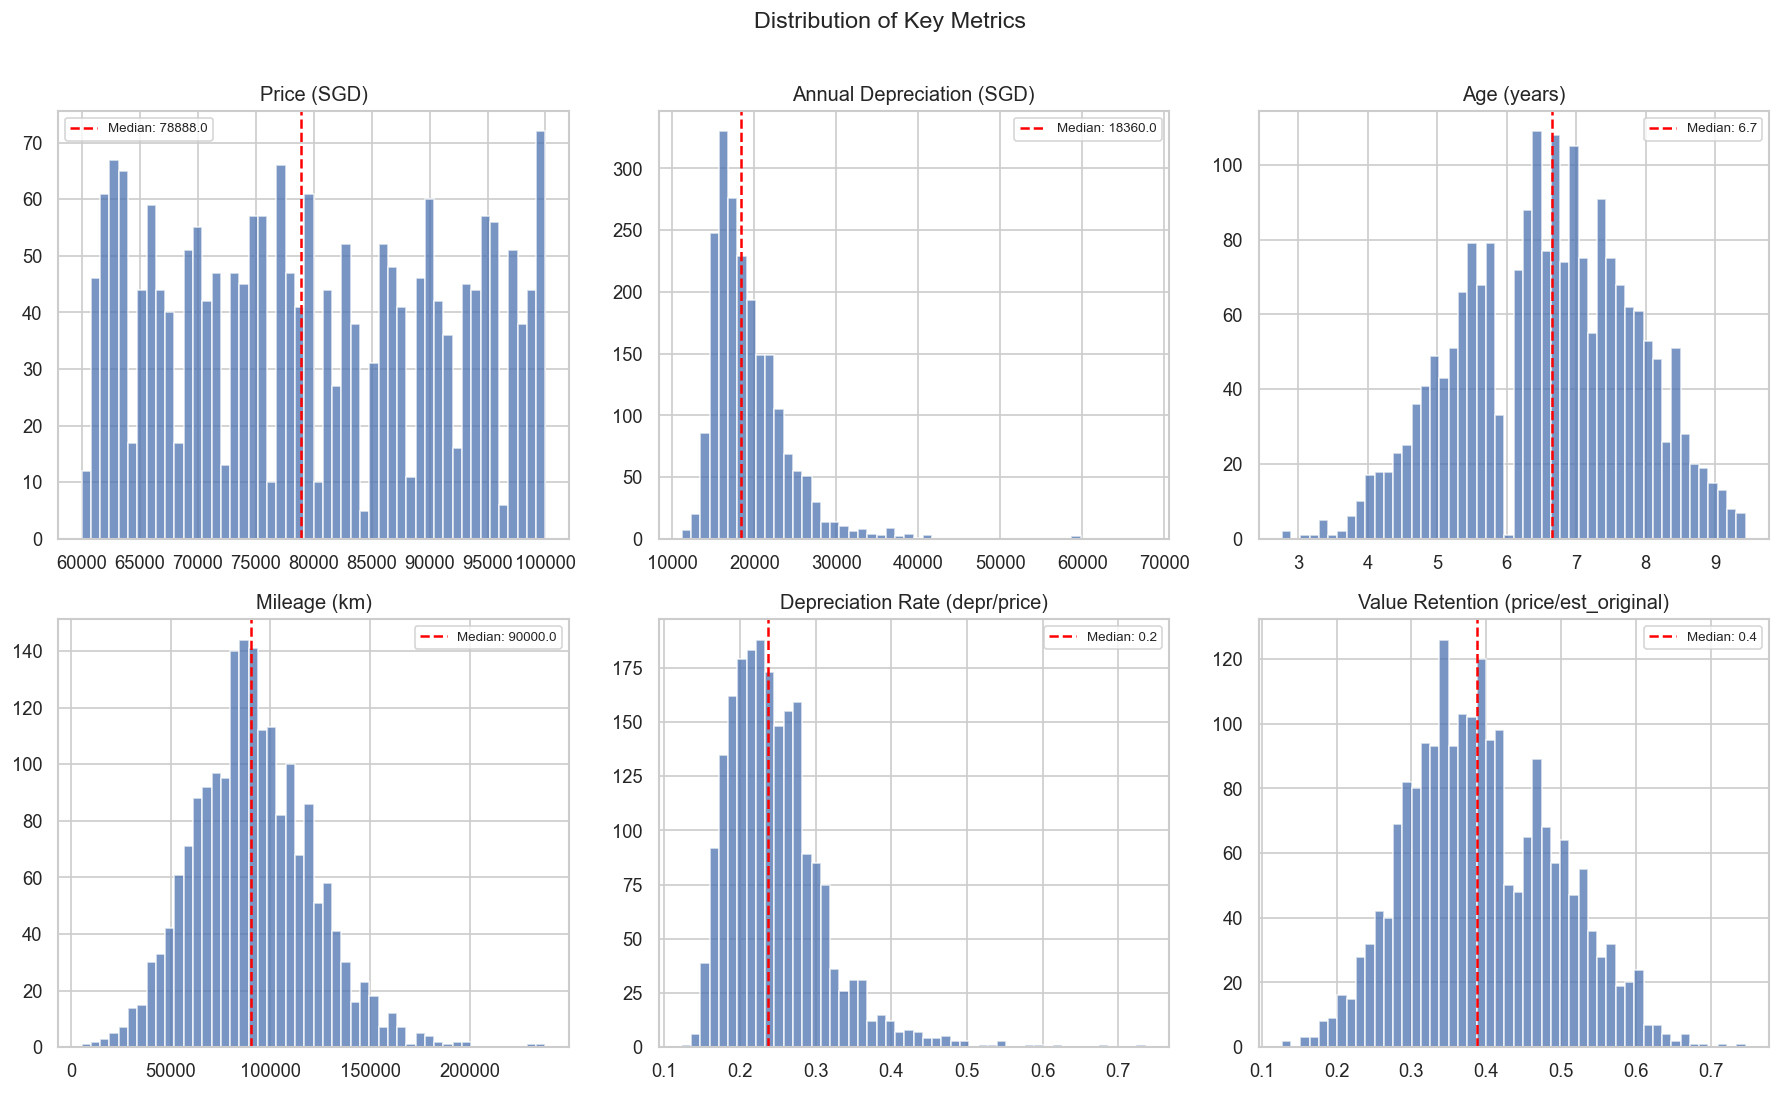

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
metrics = [
    ('price', 'Price (SGD)'), ('depreciation', 'Annual Depreciation (SGD)'),
    ('age_years', 'Age (years)'), ('mileage_km', 'Mileage (km)'),
    ('depreciation_rate', 'Depreciation Rate (depr/price)'),
    ('value_retention', 'Value Retention (price/est_original)'),
]
for ax, (col, label) in zip(axes, metrics):
    data = clean[col].dropna()
    ax.hist(data, bins=50, alpha=0.75, edgecolor='white')
    ax.axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
               label=f'Median: {data.median():.1f}')
    ax.set_title(label); ax.legend(fontsize=8)
fig.suptitle('Distribution of Key Metrics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

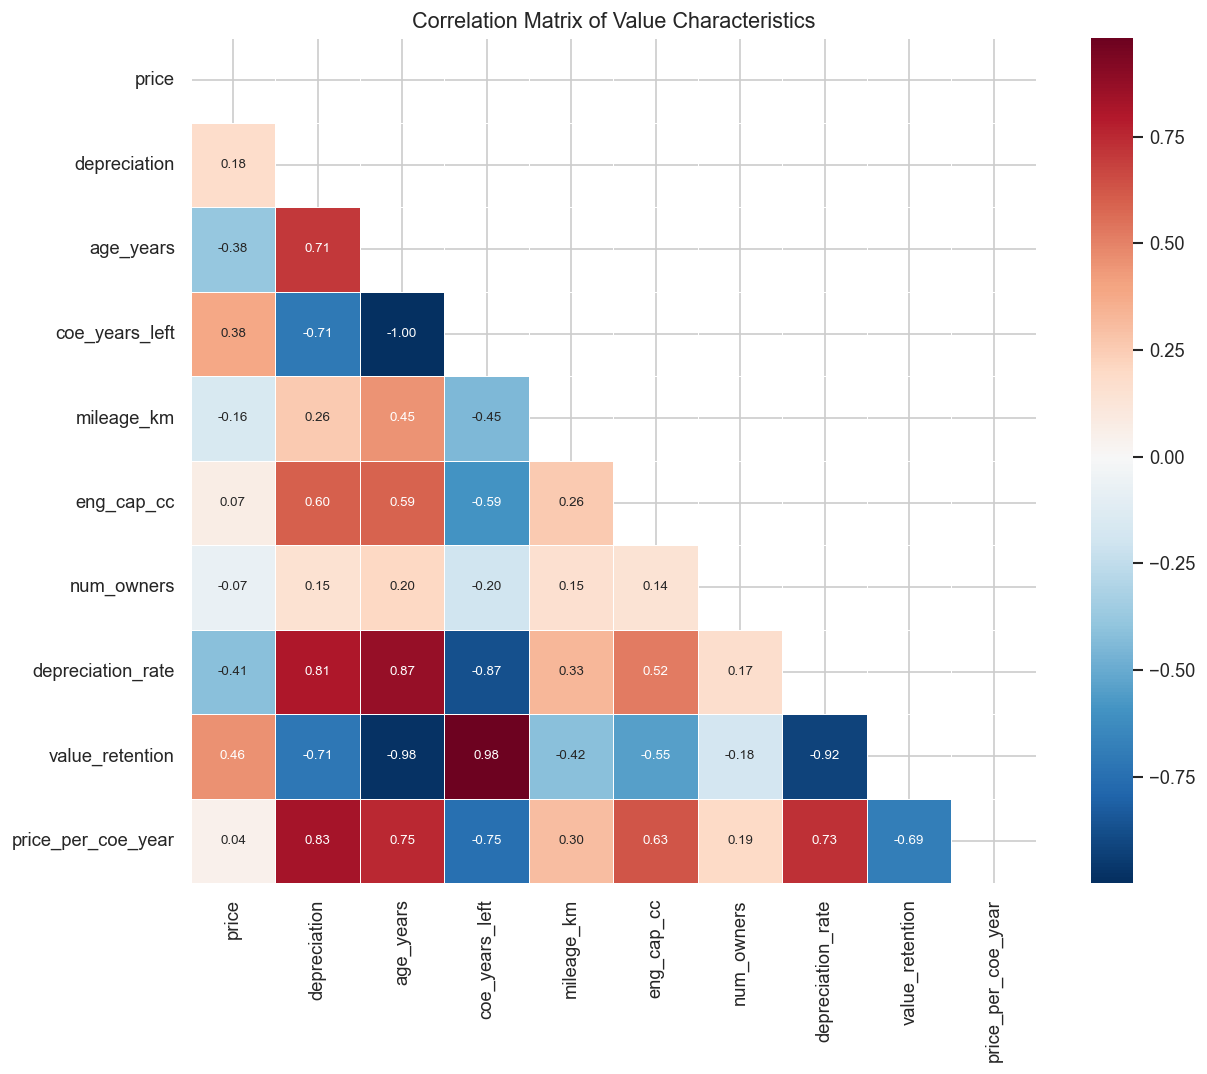

In [8]:
corr_cols = ['price', 'depreciation', 'age_years', 'coe_years_left', 'mileage_km',
             'eng_cap_cc', 'num_owners', 'depreciation_rate', 'value_retention',
             'price_per_coe_year']
corr = clean[corr_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'fontsize': 8})
ax.set_title('Correlation Matrix of Value Characteristics', fontsize=13)
plt.tight_layout(); plt.show()

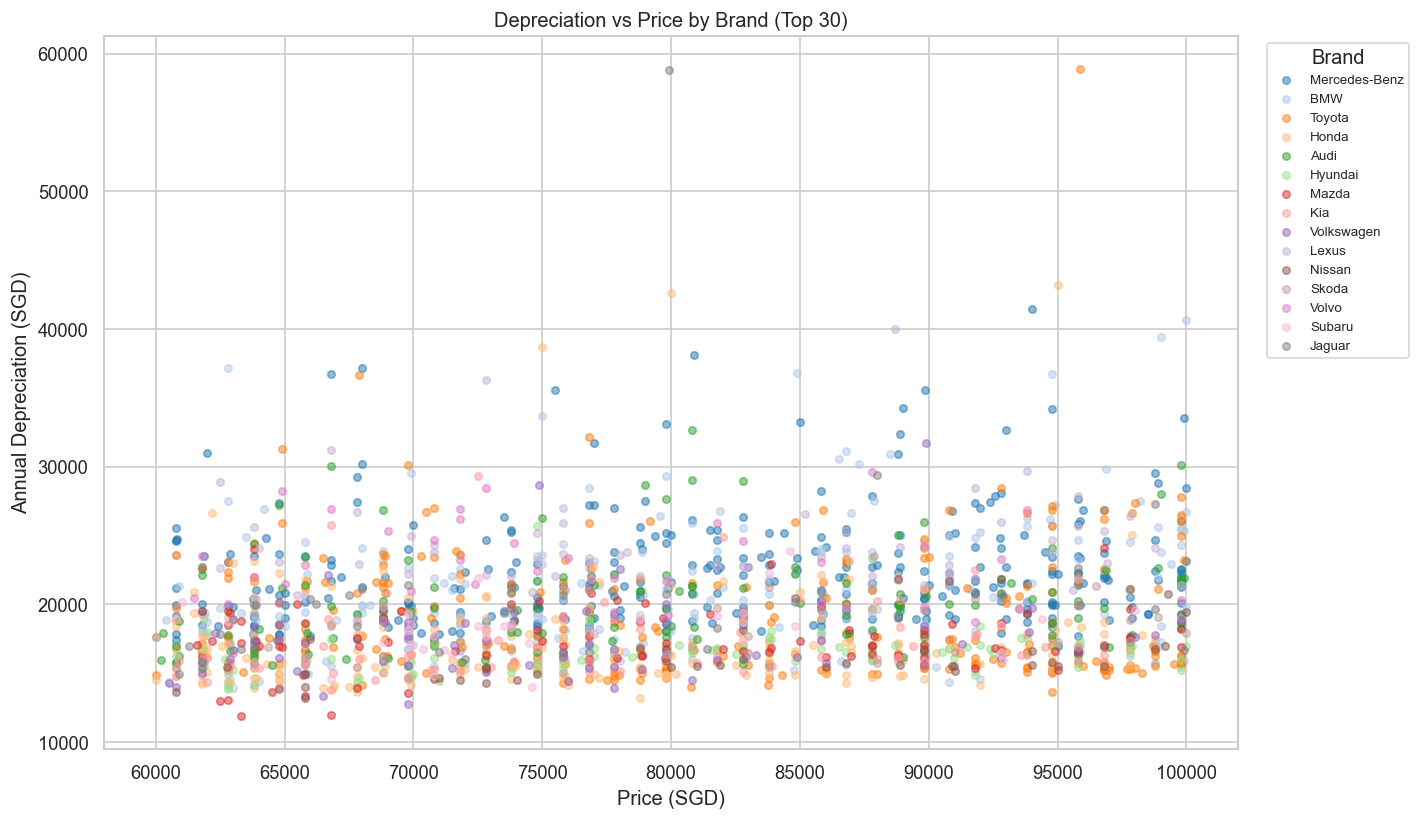

In [9]:
top_brands = clean['brand'].value_counts().head(15).index
plot_df = clean[clean['brand'].isin(top_brands)]
fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette('tab20', len(top_brands))
for i, brand in enumerate(top_brands):
    brand_data = plot_df[plot_df['brand'] == brand]
    ax.scatter(brand_data['price'], brand_data['depreciation'],
               c=[colors[i]], label=brand, alpha=0.5, s=20)
ax.set_xlabel('Price (SGD)'); ax.set_ylabel('Annual Depreciation (SGD)')
ax.set_title('Depreciation vs Price by Brand (Top 30)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, title='Brand')
plt.tight_layout(); plt.show()

In [10]:
print('## Top 30 — Lowest Depreciation Rate\n')
for i, (_, row) in enumerate(clean.nsmallest(30, 'depreciation_rate').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | Depr: ${row['depreciation']:,.0f}/yr ({row['depreciation_rate']*100:.1f}% of price)")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 30 — Lowest Depreciation Rate

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)**
   Price: $99,800 | Depr: $12,250/yr (12.3% of price)
   Age: 2.8y | COE left: 7.2y | Mileage: 20,500 km | Brand: Peugeot

2. **Opel Mokka 1.2A Turbo GS**
   Price: $99,800 | Depr: $13,630/yr (13.7% of price)
   Age: 2.9y | COE left: 7.1y | Mileage: 36,088 km | Brand: Opel

3. **Peugeot 3008 1.2A PureTech EAT8 Allure Premium**
   Price: $97,777 | Depr: $13,780/yr (14.1% of price)
   Age: 4.1y | COE left: 5.9y | Mileage: 131,752 km | Brand: Peugeot

4. **Opel Crossland 1.2A X Turbo**
   Price: $96,888 | Depr: $13,700/yr (14.1% of price)
   Age: 3.1y | COE left: 6.8y | Mileage: 24,783 km | Brand: Opel

5. **Toyota Yaris 1.0A XB**
   Price: $94,800 | Depr: $13,630/yr (14.4% of price)
   Age: 3.2y | COE left: 6.8y | Mileage: 43,000 km | Brand: Toyota

6. **Mitsubishi Space Star 1.2A**
   Price: $88,800 | Depr: $12,960/yr (14.6% of price)
   Age: 3.3y | COE left: 6.6y | Mileage: 5,200 km | Bran

In [11]:
print('## Top 30 — Highest Value Retention\n')
for i, (_, row) in enumerate(clean.nlargest(30, 'value_retention').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | Est Original: ${row['est_original_price']:,.0f} | Retention: {row['value_retention']:.1%}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 30 — Highest Value Retention

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)**
   Price: $99,800 | Est Original: $133,674 | Retention: 74.7%
   Age: 2.8y | COE left: 7.2y | Mileage: 20,500 km | Brand: Peugeot

2. **Opel Mokka 1.2A Turbo GS**
   Price: $99,800 | Est Original: $138,833 | Retention: 71.9%
   Age: 2.9y | COE left: 7.1y | Mileage: 36,088 km | Brand: Opel

3. **Opel Crossland 1.2A X Turbo**
   Price: $96,888 | Est Original: $139,535 | Retention: 69.4%
   Age: 3.1y | COE left: 6.8y | Mileage: 24,783 km | Brand: Opel

4. **Toyota Yaris 1.0A XB**
   Price: $94,800 | Est Original: $138,871 | Retention: 68.3%
   Age: 3.2y | COE left: 6.8y | Mileage: 43,000 km | Brand: Toyota

5. **Citroen C4 1.2A PureTech Feel**
   Price: $93,800 | Est Original: $139,560 | Retention: 67.2%
   Age: 3.3y | COE left: 6.6y | Mileage: 179,546 km | Brand: Citroen

6. **Mitsubishi Space Star 1.2A**
   Price: $88,800 | Est Original: $132,124 | Retention: 67.2%
   Age: 3.3y | COE left: 6

In [12]:
print('## Top 30 — Lowest Price per COE Year\n')
for i, (_, row) in enumerate(clean.nsmallest(30, 'price_per_coe_year').iterrows()):
    print(f"{i+1}. **{row['title']}**")
    print(f"   Price: ${row['price']:,.0f} | COE left: {row['coe_years_left']:.1f}y | ${row['price_per_coe_year']:,.0f}/COE-year")
    print(f"   Depr: ${row['depreciation']:,.0f}/yr | Age: {row['age_years']:.1f}y | Mileage: {row['mileage_km']:,.0f} km | Brand: {row['brand']}")
    print()

## Top 30 — Lowest Price per COE Year

1. **Mitsubishi Space Star 1.2A**
   Price: $88,800 | COE left: 6.6y | $13,489/COE-year
   Depr: $12,960/yr | Age: 3.3y | Mileage: 5,200 km | Brand: Mitsubishi

2. **Mazda Axela 1.5A**
   Price: $63,300 | COE left: 4.7y | $13,564/COE-year
   Depr: $11,870/yr | Age: 5.3y | Mileage: 72,000 km | Brand: Mazda

3. **Citroen C5 Aircross 1.2A PureTech EAT8 Feel**
   Price: $84,800 | COE left: 6.2y | $13,568/COE-year
   Depr: $13,020/yr | Age: 3.7y | Mileage: nan km | Brand: Citroen

4. **Mazda Axela Diesel 1.5A**
   Price: $66,800 | COE left: 4.9y | $13,586/COE-year
   Depr: $11,980/yr | Age: 5.1y | Mileage: 91,000 km | Brand: Mazda

5. **Opel Crossland Diesel 1.5A X Turbo**
   Price: $65,777 | COE left: 4.8y | $13,609/COE-year
   Depr: $11,130/yr | Age: 5.1y | Mileage: 66,000 km | Brand: Opel

6. **Mazda 2 HB 1.5A Deluxe**
   Price: $62,500 | COE left: 4.6y | $13,636/COE-year
   Depr: $12,970/yr | Age: 5.4y | Mileage: 62,800 km | Brand: Mazda

7. **Mits

In [13]:
print('## Top 30 — Lowest Body-Only Depreciation Rate\n')
print('Body depreciation = annual depreciation / (price - remaining COE value).')
print('Lower is better — isolates actual vehicle depreciation, excluding COE decay.\n')
for i, (_, row) in enumerate(clean.nsmallest(30, 'body_depreciation_rate').iterrows()):
    print(f"{i+1}. **{row['title']}** ({row['brand']})")
    print(f"   Price: ${row['price']:,.0f} | COE value: ${row['est_coe_value']:,.0f} | Body price: ${row['body_price']:,.0f}")
    print(f"   Body depr rate: {row['body_depreciation_rate']:.1%} | Total depr rate: {row['depreciation_rate']:.1%}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | {row['coe_category']}")
    print()

## Top 30 — Lowest Body-Only Depreciation Rate

Body depreciation = annual depreciation / (price - remaining COE value).
Lower is better — isolates actual vehicle depreciation, excluding COE decay.

1. **Opel Crossland Diesel 1.5A X Turbo** (Opel)
   Price: $65,777 | COE value: $60,044 | Body price: $5,733
   Body depr rate: -22.6% | Total depr rate: 16.9%
   Age: 5.1y | COE left: 4.8y | Category A

2. **Ssangyong Tivoli Diesel 1.6A Standard** (Ssangyong)
   Price: $67,900 | COE value: $61,079 | Body price: $6,821
   Body depr rate: -10.5% | Total depr rate: 17.2%
   Age: 5.0y | COE left: 4.9y | Category A

3. **Mazda Axela 1.5A** (Mazda)
   Price: $63,300 | COE value: $57,974 | Body price: $5,326
   Body depr rate: -10.4% | Total depr rate: 18.8%
   Age: 5.3y | COE left: 4.7y | Category A

4. **Ssangyong Tivoli Diesel 1.6A** (Ssangyong)
   Price: $67,900 | COE value: $61,079 | Body price: $6,821
   Body depr rate: -10.3% | Total depr rate: 17.3%
   Age: 5.0y | COE left: 4.9y | Categor

In [14]:
print('## Top 30 — Lowest Body Price per COE Year\n')
print('Body price per COE year = (price - COE value) / years left.')
print('This is what you actually pay per year for the vehicle, net of COE.\n')
for i, (_, row) in enumerate(clean.nsmallest(30, 'body_price_per_coe_year').iterrows()):
    print(f"{i+1}. **{row['title']}** ({row['brand']})")
    print(f"   Price: ${row['price']:,.0f} | COE value: ${row['est_coe_value']:,.0f} | Body: ${row['body_price']:,.0f}")
    print(f"   Body $/yr: ${row['body_price_per_coe_year']:,.0f} | Total $/yr: ${row['price_per_coe_year']:,.0f}")
    print(f"   Age: {row['age_years']:.1f}y | COE left: {row['coe_years_left']:.1f}y | {row['coe_category']}")
    print()

## Top 30 — Lowest Body Price per COE Year

Body price per COE year = (price - COE value) / years left.
This is what you actually pay per year for the vehicle, net of COE.

1. **Mitsubishi Space Star 1.2A** (Mitsubishi)
   Price: $88,800 | COE value: $81,784 | Body: $7,016
   Body $/yr: $1,066 | Total $/yr: $13,489
   Age: 3.3y | COE left: 6.6y | Category A

2. **Mazda Axela 1.5A** (Mazda)
   Price: $63,300 | COE value: $57,974 | Body: $5,326
   Body $/yr: $1,141 | Total $/yr: $13,564
   Age: 5.3y | COE left: 4.7y | Category A

3. **Citroen C5 Aircross 1.2A PureTech EAT8 Feel** (Citroen)
   Price: $84,800 | COE value: $77,643 | Body: $7,157
   Body $/yr: $1,145 | Total $/yr: $13,568
   Age: 3.7y | COE left: 6.2y | Category A

4. **Mazda Axela Diesel 1.5A** (Mazda)
   Price: $66,800 | COE value: $61,079 | Body: $5,721
   Body $/yr: $1,164 | Total $/yr: $13,586
   Age: 5.1y | COE left: 4.9y | Category A

5. **Opel Crossland Diesel 1.5A X Turbo** (Opel)
   Price: $65,777 | COE value: $60,

In [15]:
brand_stats = clean.groupby('brand').agg(
    count=('id', 'count'), median_price=('price', 'median'),
    median_depreciation_rate=('depreciation_rate', 'median'),
    median_value_retention=('value_retention', 'median'),
    median_price_per_coe_year=('price_per_coe_year', 'median'),
    median_age=('age_years', 'median'), median_mileage=('mileage_km', 'median'),
).query('count >= 10').sort_values('median_depreciation_rate')

print('## Brand Value Rankings (min 10 listings)\n')
print(f"{'Brand':<20} {'#':>4} {'Med Price':>10} {'Med DeprRate':>11} {'Med Retention':>12} {'Med $/COEyr':>11}")
print('-' * 72)
for brand, row in brand_stats.iterrows():
    print(f"{brand:<20} {int(row['count']):>4} ${row['median_price']:>8,.0f} "
          f"{row['median_depreciation_rate']:>10.1%} {row['median_value_retention']:>11.1%} "
          f"${row['median_price_per_coe_year']:>9,.0f}")
print()
print('## Top 30 Brands by Lowest Depreciation Rate')
for i, (brand, row) in enumerate(brand_stats.head(10).iterrows()):
    print(f"{i+1}. **{brand}** — {row['median_depreciation_rate']:.1%} depr rate, "
          f"{row['median_value_retention']:.1%} retention, "
          f"${row['median_price']:,.0f} median price ({int(row['count'])} listings)")

## Brand Value Rankings (min 10 listings)

Brand                   #  Med Price Med DeprRate Med Retention Med $/COEyr
------------------------------------------------------------------------
Citroen                19 $  89,800      16.4%       58.9% $   17,411
Peugeot                27 $  85,955      17.3%       52.8% $   18,844
Opel                   18 $  74,694      18.4%       53.4% $   14,947
MG                     17 $  89,800      18.9%       50.4% $   18,905
Nissan                 49 $  82,800      20.0%       48.2% $   17,158
Suzuki                 18 $  74,400      20.5%       46.6% $   17,395
Hyundai                97 $  80,300      20.7%       47.0% $   17,511
Mazda                  86 $  78,944      20.7%       45.4% $   19,735
Mitsubishi             36 $  77,650      20.9%       45.5% $   21,086
SEAT                   14 $  70,400      21.1%       44.9% $   19,542
Honda                 217 $  73,988      22.3%       43.2% $   18,981
Kia                    75 $  73,300   

In [16]:
scoring = clean[['depreciation_rate', 'value_retention', 'price_per_coe_year',
                   'body_depreciation_rate', 'body_price_per_coe_year',
                   'mileage_km', 'age_years']].dropna().copy()

# Annual mileage — normalises wear against age. Cap at 50,000 km/yr.
scoring['annual_mileage'] = scoring['mileage_km'] / scoring['age_years']
am_cap = 50000
scoring['annual_mileage'] = scoring['annual_mileage'].clip(upper=am_cap)

# Normalise all metrics to 0-1 range
d_min, d_max = scoring['depreciation_rate'].min(), scoring['depreciation_rate'].max()
r_min, r_max = scoring['value_retention'].min(), scoring['value_retention'].max()
p_min, p_max = scoring['price_per_coe_year'].min(), scoring['price_per_coe_year'].max()
bd_min, bd_max = scoring['body_depreciation_rate'].min(), scoring['body_depreciation_rate'].max()
bp_min, bp_max = scoring['body_price_per_coe_year'].min(), scoring['body_price_per_coe_year'].max()
m_min, m_max = scoring['annual_mileage'].min(), scoring['annual_mileage'].max()

scoring['depr_score'] = 1 - (scoring['depreciation_rate'] - d_min) / (d_max - d_min)
scoring['retention_score'] = (scoring['value_retention'] - r_min) / (r_max - r_min)
scoring['body_depr_score'] = 1 - (scoring['body_depreciation_rate'] - bd_min) / (bd_max - bd_min)
scoring['body_ppy_score'] = 1 - (scoring['body_price_per_coe_year'] - bp_min) / (bp_max - bp_min)
scoring['mileage_score'] = 1 - (scoring['annual_mileage'] - m_min) / (m_max - m_min)

# Composite score: body-depr gets highest weight — it reveals true vehicle value
scoring['composite_score'] = (
    scoring['body_depr_score'] * 0.30 +
    scoring['retention_score']   * 0.25 +
    scoring['body_ppy_score']    * 0.20 +
    scoring['depr_score']        * 0.10 +
    scoring['mileage_score']     * 0.15
)

clean_scored = clean.loc[scoring.index].copy()
clean_scored['composite_score'] = scoring['composite_score']
clean_scored['annual_mileage'] = scoring['annual_mileage']

print('## Top 30 — Composite Value Score (COE-Adjusted)\n')
print('Score = 0.30 x body_depr + 0.25 x retention + 0.20 x body_ppy + 0.10 x total_depr + 0.15 x mileage\n')
for i, (_, row) in enumerate(clean_scored.nlargest(30, 'composite_score').iterrows()):
    print(f"{i+1}. **{row['title']}** ({row['brand']}) — Score: {row['composite_score']:.3f}")
    print(f"   ${row['price']:,.0f} | COE: ${row['est_coe_value']:,.0f} | Body: ${row['body_price']:,.0f}")
    print(f"   Body depr rate: {row['body_depreciation_rate']:.1%} | Total depr rate: {row['depreciation_rate']:.1%} | "
          f"Retention: {row['value_retention']:.1%}")
    print(f"   Body $/yr: ${row['body_price_per_coe_year']:,.0f} | Age: {row['age_years']:.1f}y | "
          f"COE left: {row['coe_years_left']:.1f}y | {row['coe_category']}")
    print()

## Top 30 — Composite Value Score (COE-Adjusted)

Score = 0.30 x body_depr + 0.25 x retention + 0.20 x body_ppy + 0.10 x total_depr + 0.15 x mileage

1. **Peugeot 2008 1.2A PureTech EAT8 Allure Premium (OPC)** (Peugeot) — Score: 0.908
   $99,800 | COE: $89,031 | Body: $10,769
   Body depr rate: -1.6% | Total depr rate: 12.3% | Retention: 74.7%
   Body $/yr: $1,503 | Age: 2.8y | COE left: 7.2y | Category A

2. **Opel Crossland Diesel 1.5A X Turbo** (Opel) — Score: 0.872
   $65,777 | COE: $60,044 | Body: $5,733
   Body depr rate: -22.6% | Total depr rate: 16.9% | Retention: 53.6%
   Body $/yr: $1,186 | Age: 5.1y | COE left: 4.8y | Category A

3. **Mitsubishi Space Star 1.2A** (Mitsubishi) — Score: 0.861
   $88,800 | COE: $81,784 | Body: $7,016
   Body depr rate: 7.7% | Total depr rate: 14.6% | Retention: 67.2%
   Body $/yr: $1,066 | Age: 3.3y | COE left: 6.6y | Category A

4. **Opel Crossland 1.2A X Turbo** (Opel) — Score: 0.839
   $96,888 | COE: $84,890 | Body: $11,998
   Body depr rate

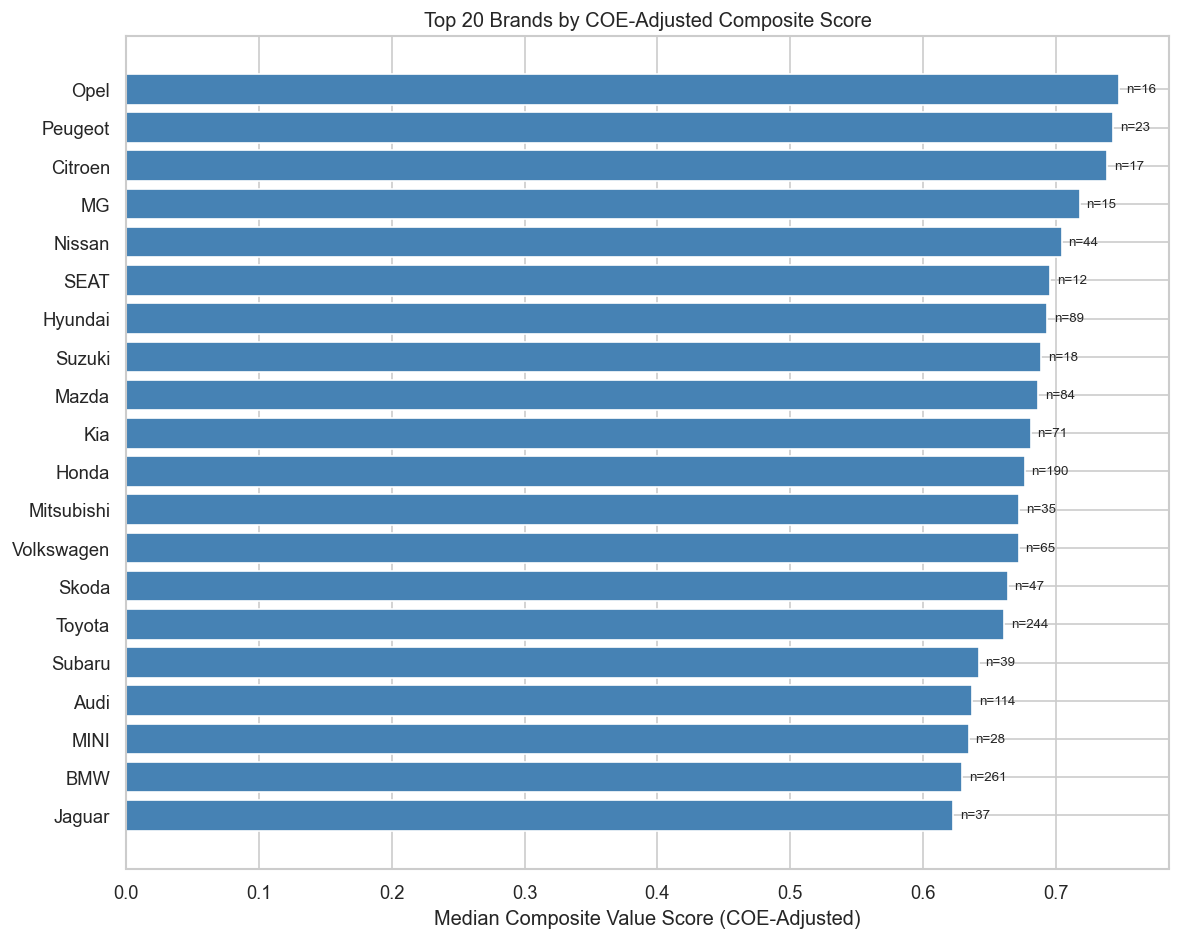

## Brand Value Rankings — COE-Adjusted Composite Score (min 10 listings)

Brand                   #  Med Price Med BodyDepr Med Body$/yr  Med Score
------------------------------------------------------------------------
Opel                   16 $  74,694       10.5% $    2,713     0.748
Peugeot                23 $  85,955       10.9% $    6,829     0.743
Citroen                17 $  90,800       10.8% $    5,177     0.739
MG                     15 $  89,800       15.0% $    6,324     0.718
Nissan                 44 $  81,444       14.5% $    4,739     0.704
SEAT                   12 $  73,700       13.9% $    7,375     0.696
Hyundai                89 $  79,800       16.6% $    5,069     0.694
Suzuki                 18 $  74,400       14.7% $    4,972     0.689
Mazda                  84 $  78,944       15.8% $    7,107     0.687
Kia                    71 $  73,300       15.5% $    5,755     0.681
Honda                 190 $  73,938       16.8% $    6,627     0.677
Mitsubishi          

In [17]:
brand_composite = clean_scored.groupby('brand').agg(
    count=('id', 'count'), median_score=('composite_score', 'median'),
    median_price=('price', 'median'), median_body_depr=('body_depreciation_rate', 'median'),
    median_body_ppy=('body_price_per_coe_year', 'median'),
    median_depr_rate=('depreciation_rate', 'median'),
    median_retention=('value_retention', 'median'),
).query('count >= 10').sort_values('median_score', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_n = min(20, len(brand_composite))
plot_brands = brand_composite.head(top_n)
ax.barh(range(len(plot_brands)), plot_brands['median_score'], color='steelblue')
ax.set_yticks(range(len(plot_brands)))
ax.set_yticklabels(plot_brands.index); ax.invert_yaxis()
ax.set_xlabel('Median Composite Value Score (COE-Adjusted)')
ax.set_title(f'Top {top_n} Brands by COE-Adjusted Composite Score')
for i, (_, row) in enumerate(plot_brands.iterrows()):
    ax.text(row['median_score'] + 0.005, i, f"n={int(row['count'])}", va='center', fontsize=8)
plt.tight_layout(); plt.show()

print('## Brand Value Rankings — COE-Adjusted Composite Score (min 10 listings)\n')
print(f"{'Brand':<20} {'#':>4} {'Med Price':>10} {'Med BodyDepr':>12} {'Med Body$/yr':>11} {'Med Score':>10}")
print('-' * 72)
for brand, row in brand_composite.iterrows():
    print(f"{brand:<20} {int(row['count']):>4} ${row['median_price']:>8,.0f} "
          f"{row['median_body_depr']:>11.1%} ${row['median_body_ppy']:>9,.0f} "
          f"{row['median_score']:>9.3f}")
print()
print('## Top 10 Brands by COE-Adjusted Composite Score')
for i, (brand, row) in enumerate(brand_composite.head(10).iterrows()):
    print(f"{i+1}. **{brand}** — Score: {row['median_score']:.3f} | "
          f"Body depr: {row['median_body_depr']:.1%} | "
          f"Body $/yr: ${row['median_body_ppy']:,.0f} | "
          f"${row['median_price']:,.0f} median ({int(row['count'])} listings)")

## Summary & Caveats

### Data Filters Applied
- Price bracket: SGD $60K–$100K
- Registration year >= 2016 (API filter)
- Vehicle type: All Passenger Cars (`vts=2`) — excludes vans/commercial
- COE-renewed cars excluded (title-based post-filter)

### COE Adjustment (New)
The COE (Certificate of Entitlement) is a government tax — a 10-year right to own a car. When buying used, part of the price is the remaining COE value. We strip this out to reveal the actual car body value:

- **COE category** assigned by engine capacity (≤1600cc → Cat A, >1600cc → Cat B)
- **Remaining COE value** = latest COE premium × (years_left / 10)
- **Body price** = total price − remaining COE value
- **Body depreciation rate** = annual depreciation / body price
- **Body price per COE year** = body price / years_left

### Key Findings
The composite score now weights body-value metrics most heavily:
1. **Body depreciation rate** (30% weight) — true vehicle depreciation, net of COE
2. **Value retention** (25% weight) — how well the car holds its original value
3. **Body price per COE year** (20% weight) — yearly cost for the vehicle itself
4. **Total depreciation rate** (10% weight) — original metric as a sanity check
5. **Annual mileage** (15% weight) — lower km/yr relative to age indicates less wear

### Data Limitations
- **Depreciation is seller-stated**, not independently computed
- **COE category** is estimated from engine capacity only (no power data); some ≤1600cc cars may actually be Cat B (>97kW)
- **Estimated original price** is a rough linear extrapolation (`price + depreciation * age`)
- **OMV, ARF, dereg_value** are available via the detail-page scraper but require per-car page loads
- The data represents a **single snapshot** (2026-05-23); trends over time may differ
- **Current COE premium** is used as a proxy for the COE's present value; actual COE was paid at registration time